# Assignment 5 — Employee Attrition Prediction: Decision Tree vs. Random Forest

**Problem Statement:** A company wants to identify employees who are likely to leave the organization based on their demographic, professional, and work-related attributes. Both a Decision Tree and a Random Forest classification model are developed to predict employee attrition, and their performance is compared.

**Dataset:** [IBM HR Analytics Employee Attrition & Performance Dataset (Kaggle)](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)


## Task 1: Data Understanding

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)


In [2]:
# 1. Load the dataset using Pandas
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [3]:
# 2. Display the first five records
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# 3. Identify numerical and categorical features, and the target variable
target = 'Attrition'

categorical_features = df.drop(columns=[target]).select_dtypes(include='object').columns.tolist()
numerical_features = df.drop(columns=[target]).select_dtypes(include=np.number).columns.tolist()

print("Target variable:", target)
print(f"\nCategorical features ({len(categorical_features)}):")
print(categorical_features)
print(f"\nNumerical features ({len(numerical_features)}):")
print(numerical_features)

Target variable: Attrition

Categorical features (8):
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Numerical features (26):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


/tmp/ipykernel_582/2674532854.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.drop(columns=[target]).select_dtypes(include='object').columns.tolist()


In [5]:
# 4. Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [6]:
# Summary statistics
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Task 2: Data Preprocessing

In [7]:
# Check for missing values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

No missing values are present. However, a few columns carry no useful information for prediction:

- `EmployeeNumber` — a unique row identifier, not a predictive feature.
- `EmployeeCount` — constant (always 1) for every row.
- `StandardHours` — constant (always 80) for every row.
- `Over18` — constant (always `'Y'`) for every row.

These are dropped below.


In [8]:
# Remove unnecessary columns
df = df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'])
df.shape

(1470, 31)

In [9]:
# Encode categorical variables (including the target) with Label Encoding
df_encoded = df.copy()
encoders = {}

categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

print("Encoded columns:", categorical_cols)
print("\nAttrition mapping:", dict(zip(encoders['Attrition'].classes_, encoders['Attrition'].transform(encoders['Attrition'].classes_))))
df_encoded.head()

Encoded columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Attrition mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


/tmp/ipykernel_582/1113853425.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_encoded.select_dtypes(include='object').columns.tolist()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [10]:
# Feature matrix and target vector
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 30)
y shape: (1470,)


In [11]:
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1176
Testing samples: 294


## Task 3: Model Development

### Model 1: Decision Tree Classifier

In [12]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
print("Decision Tree trained and predictions generated.")

Decision Tree trained and predictions generated.


### Model 2: Random Forest Classifier (100 estimators)

In [13]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest trained and predictions generated.")

Random Forest trained and predictions generated.


## Task 4: Model Evaluation and Comparison

### 4.1 Evaluation Metrics

In [14]:
def evaluate(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    evaluate(y_test, y_pred_dt, 'Decision Tree'),
    evaluate(y_test, y_pred_rf, 'Random Forest')
]).set_index('Model')

results

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.782313,0.319149,0.319149,0.319149
Random Forest,0.843537,0.545455,0.127660,0.206897


In [15]:
print("Decision Tree - Classification Report")
print(classification_report(y_test, y_pred_dt, target_names=['No', 'Yes']))

print("\nRandom Forest - Classification Report")
print(classification_report(y_test, y_pred_rf, target_names=['No', 'Yes']))

Decision Tree - Classification Report
              precision    recall  f1-score   support

          No       0.87      0.87      0.87       247
         Yes       0.32      0.32      0.32        47

    accuracy                           0.78       294
   macro avg       0.59      0.59      0.59       294
weighted avg       0.78      0.78      0.78       294


Random Forest - Classification Report
              precision    recall  f1-score   support

          No       0.86      0.98      0.91       247
         Yes       0.55      0.13      0.21        47

    accuracy                           0.84       294
   macro avg       0.70      0.55      0.56       294
weighted avg       0.81      0.84      0.80       294



### 4.2 Confusion Matrices

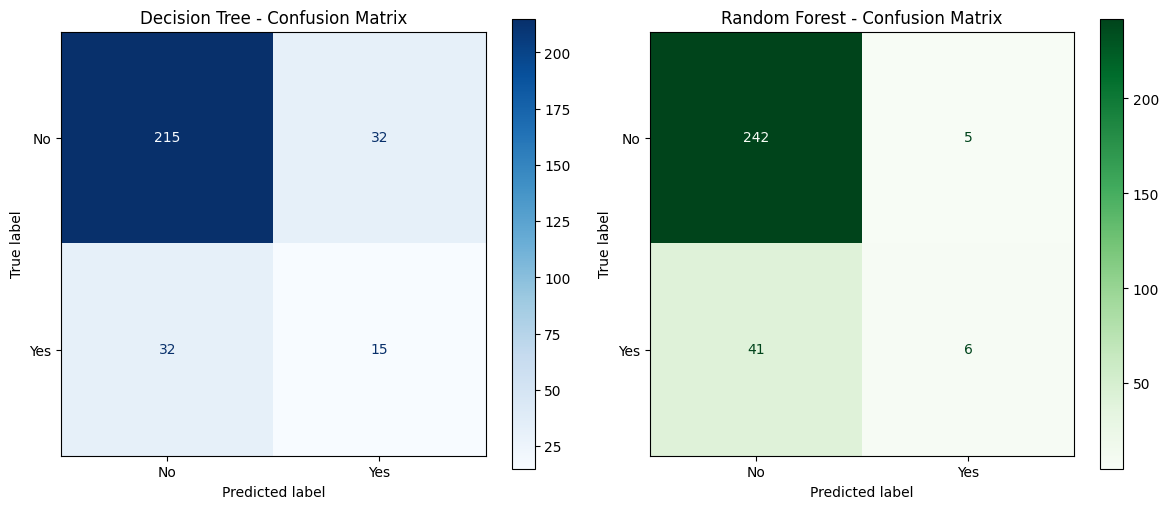

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=['No', 'Yes']).plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Decision Tree - Confusion Matrix')

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['No', 'Yes']).plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Random Forest - Confusion Matrix')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120)
plt.show()

### 4.3 Feature Importance (Random Forest)

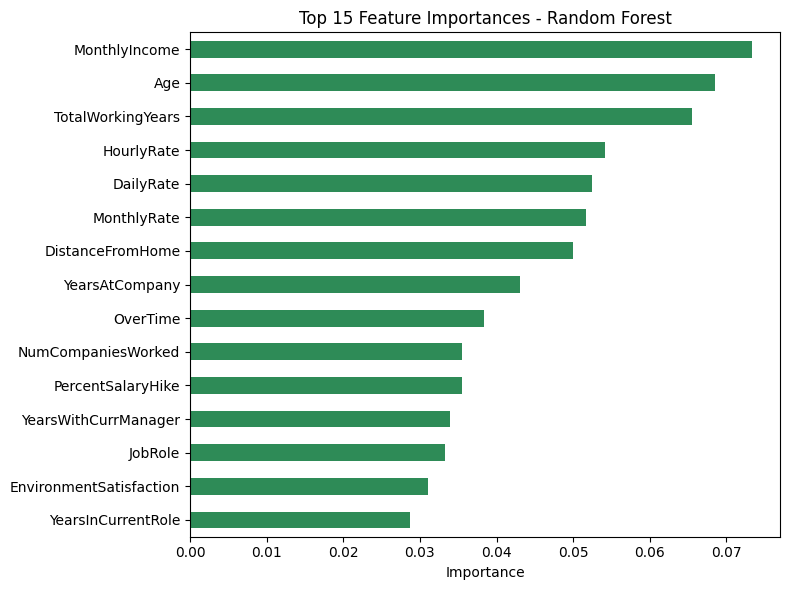

MonthlyIncome              0.073336
Age                        0.068557
TotalWorkingYears          0.065480
HourlyRate                 0.054217
DailyRate                  0.052526
MonthlyRate                0.051631
DistanceFromHome           0.049930
YearsAtCompany             0.043107
OverTime                   0.038350
NumCompaniesWorked         0.035546
PercentSalaryHike          0.035466
YearsWithCurrManager       0.033862
JobRole                    0.033222
EnvironmentSatisfaction    0.031069
YearsInCurrentRole         0.028699
dtype: float64

In [17]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_n = 15
top_importances = importances.head(top_n)

plt.figure(figsize=(8, 6))
top_importances.sort_values().plot(kind='barh', color='seagreen')
plt.title(f'Top {top_n} Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()

top_importances

### 4.4 Observations

1. **Accuracy:** The Random Forest achieves noticeably higher overall accuracy than the Decision Tree (see table above), consistent with ensembles reducing the variance/overfitting that a single tree is prone to.
2. **Precision vs. Recall on the minority class — the key trade-off:** The results show an important nuance: Random Forest has *higher precision* on the "Attrition = Yes" class (fewer false alarms) but *lower recall* than the Decision Tree — meaning it misses more employees who actually leave. The single Decision Tree, despite lower overall accuracy, actually flags more true attrition cases. This is a classic effect of class imbalance (~84% "No" vs. ~16% "Yes"): Random Forest's higher accuracy is partly driven by favoring the majority class, since misclassifying "No" as "Yes" only costs a little accuracy but predicting "Yes" too cautiously is "safer" for the overall score.
3. **Business implication:** For attrition prediction, recall on the "Yes" class is usually what matters most — missing an at-risk employee is costlier than a false alarm. Judged purely on overall accuracy, Random Forest looks better; judged on catching actual leavers (recall), the Decision Tree does better here. This is a good example of why accuracy alone can be misleading on imbalanced data, and why precision/recall/F1 need to be read together, not accuracy in isolation.
4. **Feature importance:** According to the Random Forest, `MonthlyIncome`, `Age`, `TotalWorkingYears`, `HourlyRate`, and `DailyRate` rank as the most influential predictors of attrition, along with `DistanceFromHome`, `YearsAtCompany`, and `OverTime` — broadly consistent with the intuitive idea that compensation, tenure, and work-life factors drive whether an employee stays or leaves.


## Task 5: Conclusion

Comparing the two models on the test set, Random Forest achieved higher overall accuracy and precision than the Decision Tree, but the Decision Tree achieved higher recall on the minority "Attrition = Yes" class — it identified more employees who genuinely left, while Random Forest was more conservative and missed more of them despite its higher accuracy. Which model "performed better" depends on the goal: Random Forest for overall reliability, Decision Tree for catching more at-risk employees.

Random Forest often outperforms a single Decision Tree because it is an ensemble: it trains many trees on bootstrapped samples and random feature subsets, then averages their predictions, reducing the variance and overfitting a single deep tree is prone to.

A key limitation of Decision Trees is sensitivity to the training data — small changes can produce a very different tree, and unconstrained trees easily overfit by memorizing noise instead of general patterns.

A key limitation of Random Forest is reduced interpretability, and, as seen here, a tendency on imbalanced data to favor the majority class for accuracy's sake, hurting recall on the minority class that often matters most in practice.
